<!-- Cabeçalho -->
<br />

<p align="center">
  <h1 align="center">Perfil Regional da População Indígena</h1>
</p>

## Introdução

Neste estudo, a análise passa a concentrar-se nas **Grandes Regiões brasileiras**, permitindo comparar os principais indicadores demográficos da população indígena entre Norte, Nordeste, Centro-Oeste, Sudeste e Sul.

O objetivo é investigar como a população indígena se distribui regionalmente e como esse panorama se modificou entre os Censos Demográficos de 2010 e 2022, considerando diferenças de crescimento populacional, situação do domicílio e localização em relação às Terras Indígenas.

A análise regional permite observar padrões que nem sempre são evidentes quando cada Unidade da Federação é examinada isoladamente, oferecendo uma perspectiva agregada sobre as diferenças territoriais existentes no país.

## Objetivos e perguntas analíticas

A pergunta central deste estudo é:

> **Como o crescimento e a distribuição da população indígena diferem entre as Grandes Regiões brasileiras?**

Para respondê-la, serão examinadas cinco dimensões:

1. **Crescimento populacional:** qual Grande Região apresentou o maior crescimento da população indígena entre 2010 e 2022?
2. **Urbanização:** quais regiões apresentam as maiores proporções de população indígena residente em áreas urbanas e rurais?
3. **Residência em Terras Indígenas:** como se distribui regionalmente a população indígena residente em Terras Indígenas?
4. **Residência fora de Terras Indígenas:** como se distribui regionalmente a população indígena residente fora de Terras Indígenas?
5. **Perfil territorial:** qual é o perfil regional da população indígena residente fora de Terras Indígenas e como ele se modificou entre 2010 e 2022?

Os resultados apresentados são de natureza **descritiva e comparativa**. As diferenças observadas entre os Censos de 2010 e 2022 não devem ser interpretadas, isoladamente, como evidência de migração, deslocamento populacional ou relações causais. A análise limita-se aos padrões identificáveis a partir dos dados censitários utilizados neste estudo.

In [1]:
from pathlib import Path

import geopandas as gpd 

from charts.regional_profile import PlotPerfilRegional
from charts.regional_synthesis import PainelSinteseRegional

## 1. Carregamento das base de dados

In [2]:
# Sobe as pastas até achar a raiz do projeto
ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())

# Caminhdo para o arquivo
gdf_path = (
    ROOT
    / "data"
    / "processed"
    / "geo"
    / "gdf_regioes.parquet"
)

# Caminho de saída
output_path = (
    ROOT
    / "outputs"
    / "figures"
    / "charts"
)

# Lê o arquivo Parquet contendo os dados geoespaciais das regiões
gdf_regioes = gpd.read_parquet(gdf_path)

# Salvar o DataFrame e um arquivo CSV
gdf_regioes.to_csv((
    ROOT
    / "data"
    / "processed"
    / "table"
    / "gdf_regional_profile.csv"
    ),
    index=False, 
    encoding="utf-8"
)

In [3]:
# Cria uma instância da classe PlotPerfilRegional para gerar gráficos regionais
graficos_regionais = PlotPerfilRegional(
    gdf=gdf_regioes,
    diretorio_saida=(output_path),
)

# Instancia a classe informando os dados e onde salvar os gráficos
painel = PainelSinteseRegional(
    gdf=gdf_regioes,
    diretorio_saida=Path(output_path),
)

In [4]:
gdf_regioes.head() # Exibe as primeiras linhas do GeoDataFrame para inspeção

,NM_REGIAO,geometry,Indígenas 2010 Total,Indígenas 2010 Urbano,Indígenas 2010 Rural,Indígenas 2010 TI Total,Indígenas 2010 TI Urbano,Indígenas 2010 TI Rural,Indígenas 2010 Fora TI Total,Indígenas 2010 Fora TI Urbano,Indígenas 2010 Fora TI Rural,Indígenas 2022 Total,Indígenas 2022 Urbano,Indígenas 2022 Rural,Indígenas 2022 TI Total,Indígenas 2022 TI Urbano,Indígenas 2022 TI Rural,Indígenas 2022 Fora TI Total,Indígenas 2022 Fora TI Urbano,Indígenas 2022 Fora TI Rural
0,Centro-oeste,"POLYGON ((-55.04062 -23.98082, -55.04429 -23.9...",143432,35156,108276,104019,2379,101640,39413,32777,6636,200153,75958,124195,114201,1771,112430,85952,74187,11765
1,Nordeste,"MULTIPOLYGON (((-46.01369 -10.24884, -46.01772...",232739,114401,118338,106142,19159,86983,126597,95242,31355,529128,329639,199489,129882,30200,99682,399246,299439,99807
2,Norte,"MULTIPOLYGON (((-60.80596 -13.65584, -60.81007...",342836,61565,281271,251891,2179,249712,90945,59386,31559,753780,376875,376905,316827,34974,281853,436953,341901,95052
3,Sudeste,"MULTIPOLYGON (((-48.03811 -25.35732, -48.03819...",99137,79272,19865,15904,652,15252,83233,78620,4613,123434,95348,28086,21525,1740,19785,101909,93608,8301
4,Sul,"MULTIPOLYGON (((-53.27272 -32.92798, -53.31016...",78773,34440,44333,39427,1594,37833,39346,32846,6500,88341,36926,51415,40409,1301,39108,47932,35625,12307


## 1. Qual Grande Região apresentou o maior crescimento da população indígena entre 2010 e 2022?

O crescimento percentual é dado por: 

$$\text{Crescimento (\%)} = \left( \frac{\text{Indígenas}_{2022} - \text{Indígenas}_{2010}}{\text{Indígenas}_{2010}} \right) \times 100$$

In [5]:
# 1. Calcula a variação percentual (%) da população indígena entre os censos de 2010 e 2022
gdf_regioes["Crescimento (%)"] = (
    (
        gdf_regioes["Indígenas 2022 Total"]
        - gdf_regioes["Indígenas 2010 Total"]
    )
    / gdf_regioes["Indígenas 2010 Total"]
) * 100

# 2. Seleciona colunas de dados absolutos e relativos, ordenando do maior para o menor crescimento
crescimento_regional = (
    gdf_regioes[
        [
            "NM_REGIAO",
            "Indígenas 2010 Total",
            "Indígenas 2022 Total",
            "Crescimento (%)",
        ]
    ]
    .sort_values(
        "Crescimento (%)",
        ascending=False,
    )
)

# Exibe a tabela comparativa de crescimento
crescimento_regional

,NM_REGIAO,Indígenas 2010 Total,Indígenas 2022 Total,Crescimento (%)
1,Nordeste,232739,529128,127.348231
2,Norte,342836,753780,119.866058
0,Centro-oeste,143432,200153,39.545569
3,Sudeste,99137,123434,24.508508
4,Sul,78773,88341,12.146294


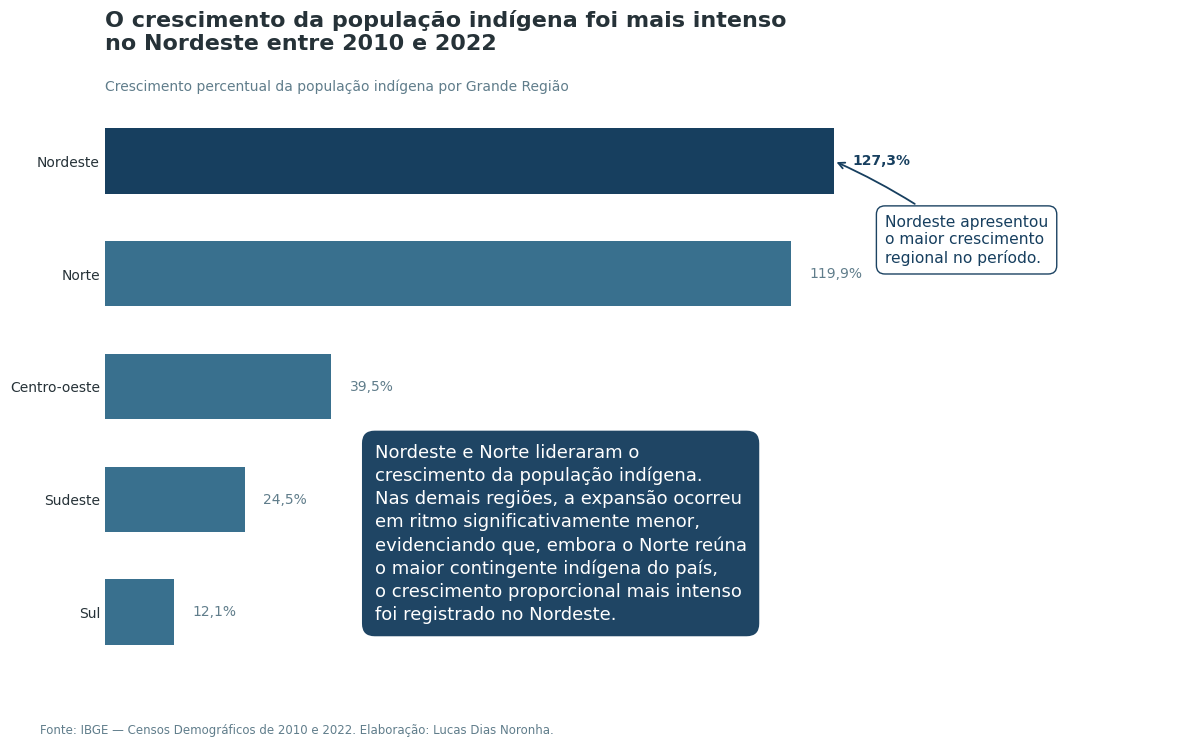

In [6]:
graficos_regionais.plot_crescimento_regional()

## Resposta
Entre 2010 e 2022, o Nordeste foi a Grande Região que apresentou o maior crescimento proporcional da população indígena, superando inclusive a Região Norte. Esse resultado evidencia que a expansão da população indígena ocorreu de forma mais acelerada no Nordeste, embora o Norte continue concentrando o maior contingente populacional indígena do Brasil.

## 2. Qual região possui a maior proporção de indígenas vivendo em áreas urbanas?

A taxa de urbanização indígena é calculada por:

$$\text{Percentual Urbano} = \left( \frac{\text{Indígenas}_{2022 \text{ Urbano}}}{\text{Indígenas}_{2022 \text{ Total}}} \right) \times 100$$

In [7]:
# 1. Calcula a taxa de urbanização (%) sobre o total da população indígena
gdf_regioes["Percentual Urbano"] = (
    gdf_regioes["Indígenas 2022 Urbano"]
    / gdf_regioes["Indígenas 2022 Total"]
) * 100

# 2. Filtra colunas, ordena de forma decrescente e reindexa a tabela (0 a N)
urbanizacao_regional = (
    gdf_regioes[
        [
            "NM_REGIAO",
            "Percentual Urbano",
        ]
    ]
    .sort_values(
        "Percentual Urbano",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Exibe o ranking de urbanização regional
urbanizacao_regional

,NM_REGIAO,Percentual Urbano
0,Sudeste,77.246140
1,Nordeste,62.298536
2,Norte,49.998010
3,Sul,41.799391
4,Centro-oeste,37.949968


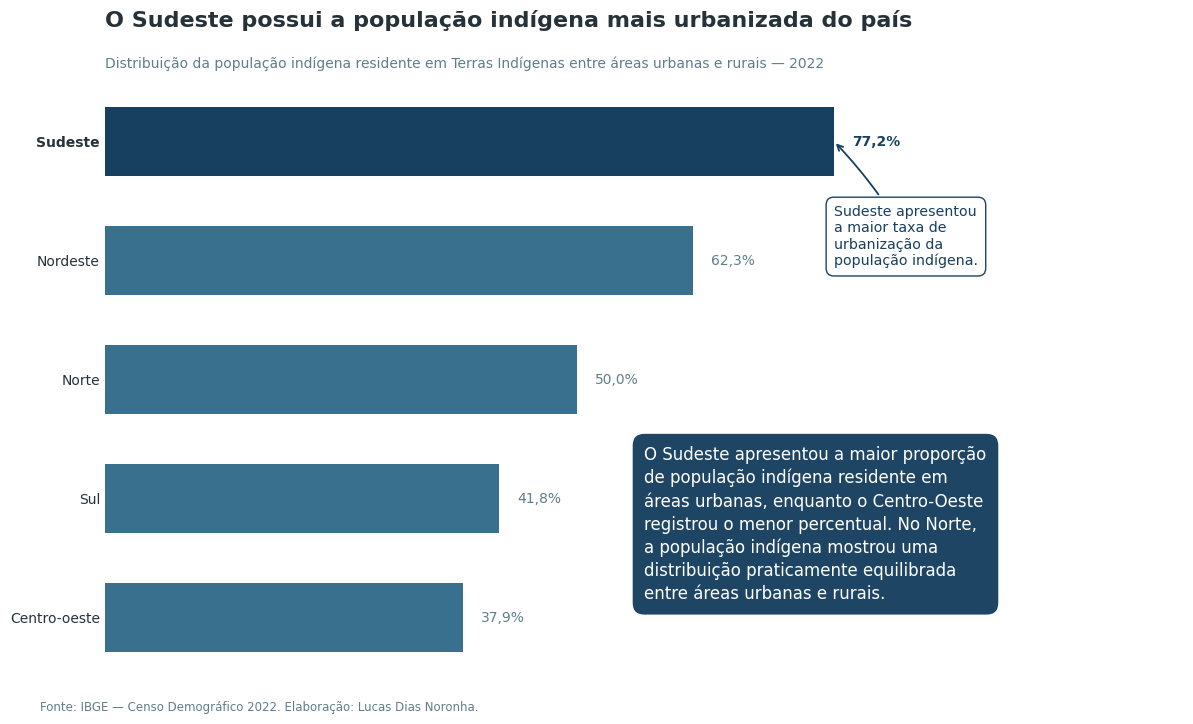

In [8]:
graficos_regionais.plot_urbanizacao_regional()

## Resposta

A Região Sudeste apresentou a maior proporção de população indígena residente em áreas urbanas, com 77,2%. Em contraste, o Centro-Oeste registrou o menor nível de urbanização (37,9%), enquanto o Norte apresentou uma distribuição praticamente equilibrada entre áreas urbanas e rurais, com 50,0% da população indígena vivendo em cidades.

## 3. A população indígena residente em Terras Indígenas é predominantemente urbana ou rural em cada Grande Região?

Proporção de Urbanização:

$$\text{Percentual TI Urbano} = \left( \frac{\text{Indígenas 2022 TI Urbano}}{\text{Indígenas 2022 TI Total}} \right) \times 100$$

Proporção da População Rural:

$$\text{Percentual TI Rural} = \left( \frac{\text{Indígenas 2022 TI Rural}}{\text{Indígenas 2022 TI Total}} \right) \times 100$$

Soma dos Percentuais: 

$$\text{Soma TI (\%)} = \text{Percentual TI Urbano} + \text{Percentual TI Rural}$$

In [9]:
# 1. Calcula a proporção (%) de indígenas em Terras Indígenas situadas em áreas URBANAS
gdf_regioes["Percentual TI Urbano"] = (
    gdf_regioes["Indígenas 2022 TI Urbano"]
    / gdf_regioes["Indígenas 2022 TI Total"]
) * 100

# 2. Calcula a proporção (%) de indígenas em Terras Indígenas situadas em áreas RURAIS
gdf_regioes["Percentual TI Rural"] = (
    gdf_regioes["Indígenas 2022 TI Rural"]
    / gdf_regioes["Indígenas 2022 TI Total"]
) * 100

# 3. Calcula a soma dos percentuais para verificação de consistência (deve resultar em 100%)
gdf_regioes["Soma TI (%)"] = (
    gdf_regioes["Percentual TI Urbano"]
    + gdf_regioes["Percentual TI Rural"]
)

# 4. Filtra as colunas de interesse, ordena da maior para a menor taxa urbana e reindexa
ti_urbano_rural = (
    gdf_regioes[
        [
            "NM_REGIAO",
            "Percentual TI Urbano",
            "Percentual TI Rural",
            "Soma TI (%)",
        ]
    ]
    .sort_values(
        "Percentual TI Urbano",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Exibe o resultado compilado
ti_urbano_rural

,NM_REGIAO,Percentual TI Urbano,Percentual TI Rural,Soma TI (%)
0,Nordeste,23.251875,76.748125,100.0
1,Norte,11.038832,88.961168,100.0
2,Sudeste,8.083624,91.916376,100.0
3,Sul,3.219580,96.780420,100.0
4,Centro-oeste,1.550775,98.449225,100.0


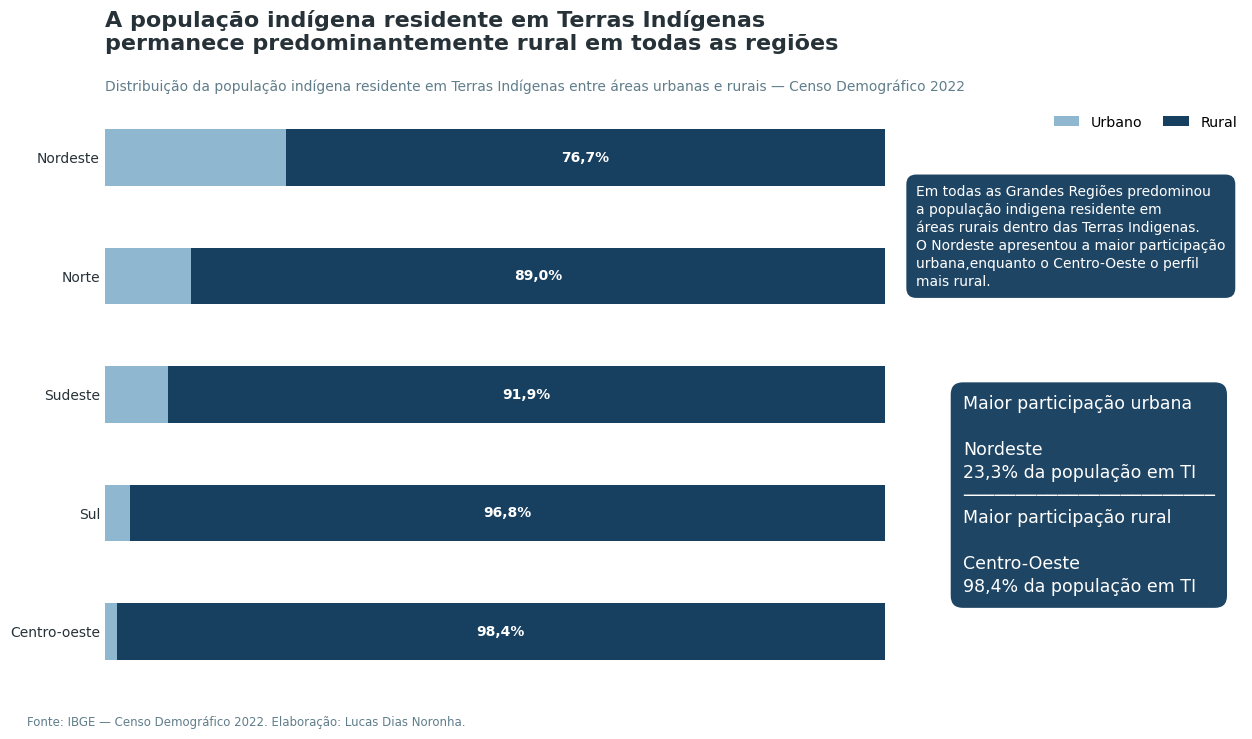

In [10]:
graficos_regionais.plot_urbanizacao_terras_indigenas() # Gera o gráfico

## Resposta

A população indígena residente em Terras Indígenas apresentou um perfil predominantemente rural em todas as Grandes Regiões brasileiras. Mesmo na região com maior participação urbana, o Nordeste, cerca de três quartos dessa população ainda viviam em áreas rurais (76,7%). Nas demais regiões, essa predominância foi ainda mais acentuada, alcançando 98,4% no Centro-Oeste.

Esse padrão indica que, embora exista urbanização dentro das Terras Indígenas, ela permanece um fenômeno relativamente restrito. A ocupação continua fortemente associada ao meio rural, característica observada de forma consistente em todas as regiões do país.

## 4. Como a população indígena residente fora de Terras Indígenas se distribui entre áreas urbanas e rurais nas Grandes Regiões?


Proporção de indígenas fora de Terras Indígenas que vivem em áreas Urbanas:

$$\text{Percentual Fora TI Urbano} = \left( \frac{\text{Indígenas 2022 Fora TI Urbano}}{\text{Indígenas 2022 Fora TI Total}} \right) \times 100$$

Oroporção de indígenas fora de Terras Indígenas que vivem em áreas Rurais:

$$\text{Percentual Fora TI Rural} = \left( \frac{\text{Indígenas 2022 Fora TI Rural}}{\text{Indígenas 2022 Fora TI Total}} \right) \times 100$$

Soma dos percentuais:

$$\text{Soma Fora TI (\%)} = \text{Percentual Fora TI Urbano} + \text{Percentual Fora TI Rural}$$

In [11]:
# 1. Calcula a proporção (%) de indígenas fora de Terras Indígenas que vivem em áreas URBANAS
gdf_regioes["Percentual Fora TI Urbano"] = (
    gdf_regioes["Indígenas 2022 Fora TI Urbano"]
    / gdf_regioes["Indígenas 2022 Fora TI Total"]
) * 100

# 2. Calcula a proporção (%) de indígenas fora de Terras Indígenas que vivem em áreas RURAIS
gdf_regioes["Percentual Fora TI Rural"] = (
    gdf_regioes["Indígenas 2022 Fora TI Rural"]
    / gdf_regioes["Indígenas 2022 Fora TI Total"]
) * 100

# 3. Calcula a soma dos percentuais para verificação de consistência (deve resultar em 100%)
gdf_regioes["Soma Fora TI (%)"] = (
    gdf_regioes["Percentual Fora TI Urbano"]
    + gdf_regioes["Percentual Fora TI Rural"]
)

# 3. Ordena o DataFrame da maior para a menor proporção urbana e reindexa as linhas
fora_ti_urbano_rural = (
    gdf_regioes
    .sort_values(
        "Percentual Fora TI Urbano",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Exibe o resultado ordenado
fora_ti_urbano_rural[
    [
        "NM_REGIAO",
        "Percentual Fora TI Urbano",
        "Percentual Fora TI Rural",
        "Soma Fora TI (%)",
    ]
]

,NM_REGIAO,Percentual Fora TI Urbano,Percentual Fora TI Rural,Soma Fora TI (%)
0,Sudeste,91.854498,8.145502,100.0
1,Centro-oeste,86.312128,13.687872,100.0
2,Norte,78.246631,21.753369,100.0
3,Nordeste,75.001127,24.998873,100.0
4,Sul,74.324042,25.675958,100.0


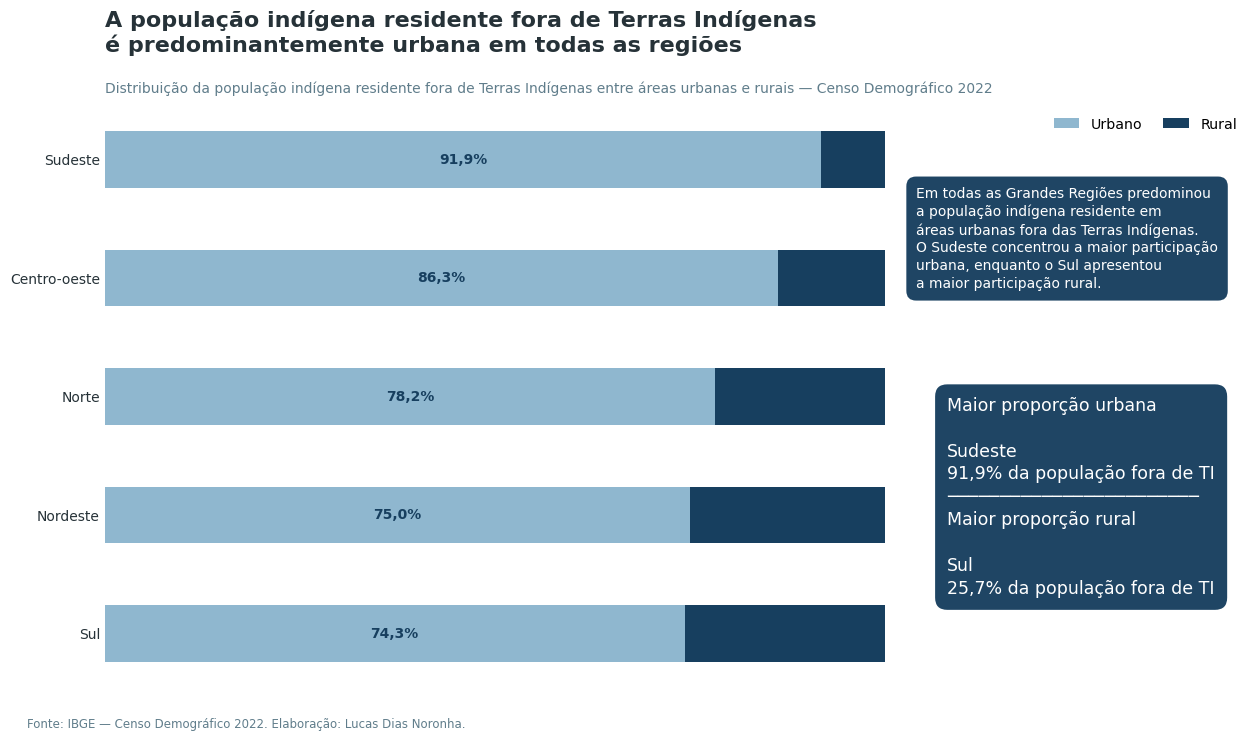

In [12]:
graficos_regionais.plot_urbanizacao_fora_terras_indigenas() # Exibe o gráfico

## Resposta

Fora das Terras Indígenas, a população indígena apresentou predominância urbana em todas as Grandes Regiões brasileiras. O Sudeste registrou a maior proporção de indígenas residentes em áreas urbanas (91,9%), enquanto o Sul apresentou a maior participação de residentes em áreas rurais (25,7%). Apesar das diferenças regionais, a urbanização predominou de forma consistente em todo o país, indicando que a população indígena que vive fora das Terras Indígenas está majoritariamente inserida em contextos urbanos.

## 5. Como o perfil de residência da população indígena varia entre Terras Indígenas e fora delas nas Grandes Regiões?

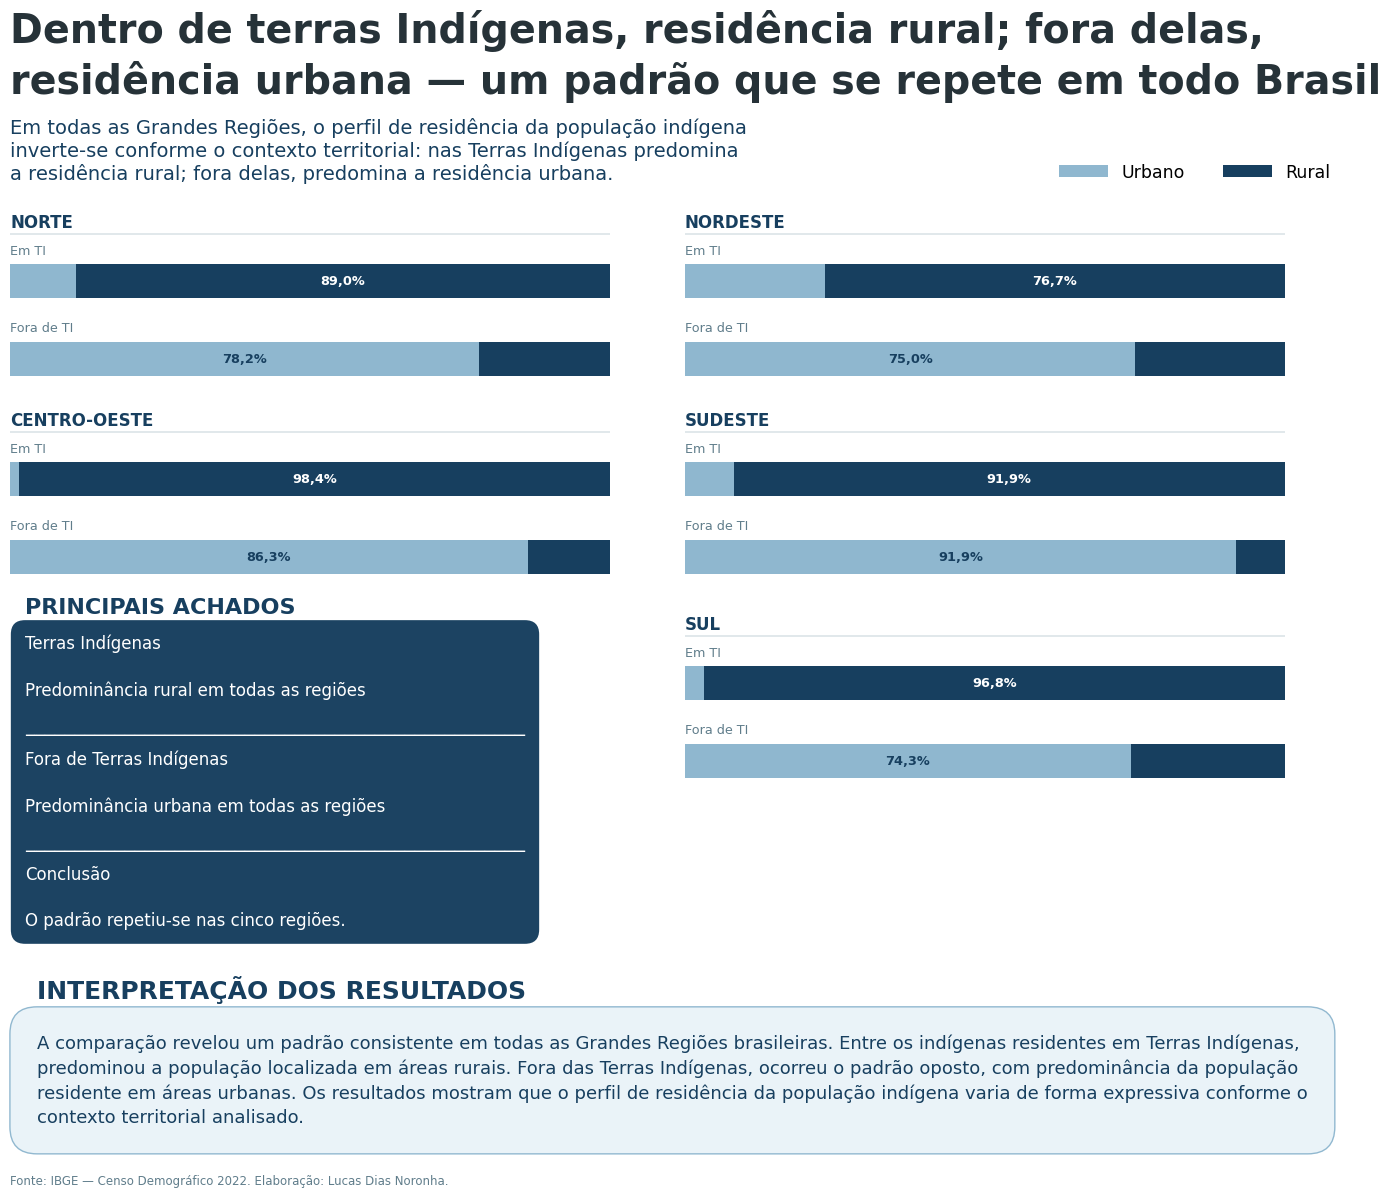

In [13]:
painel.plot()

## Resposta

Os resultados evidenciam que o perfil de residência da população indígena varia de forma consistente conforme o contexto territorial. Nas Terras Indígenas, predominou a população residente em áreas rurais em todas as Grandes Regiões, enquanto fora desses territórios predominou a residência em áreas urbanas. A uniformidade desse comportamento regional reforça a influência do contexto territorial sobre a distribuição urbano-rural da população indígena.

## Conclusão

Os resultados do Estudo 3 evidenciam que o perfil de residência da população indígena brasileira apresenta um comportamento territorial consistente. Em todas as Grandes Regiões, a população residente em Terras Indígenas concentrou-se predominantemente em áreas rurais, enquanto fora desses territórios predominou a residência em áreas urbanas. Embora a intensidade desse padrão varie regionalmente, a inversão do perfil urbano-rural repetiu-se em todas as regiões analisadas, indicando que o contexto territorial constitui um fator fortemente associado à distribuição espacial da população indígena. Esses achados reforçam a importância de considerar as especificidades territoriais nas análises demográficas e no planejamento de políticas públicas voltadas aos povos indígenas.

## Informações sobre os dados

In [14]:
gdf_regioes.info() # Exibe informações sobre o GeoDataFrame, incluindo tipos de dados e contagem de valores não nulos

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   NM_REGIAO                      5 non-null      object  
 1   geometry                       5 non-null      geometry
 2   Indígenas 2010 Total           5 non-null      int64   
 3   Indígenas 2010 Urbano          5 non-null      int64   
 4   Indígenas 2010 Rural           5 non-null      int64   
 5   Indígenas 2010 TI Total        5 non-null      int64   
 6   Indígenas 2010 TI Urbano       5 non-null      int64   
 7   Indígenas 2010 TI Rural        5 non-null      int64   
 8   Indígenas 2010 Fora TI Total   5 non-null      int64   
 9   Indígenas 2010 Fora TI Urbano  5 non-null      int64   
 10  Indígenas 2010 Fora TI Rural   5 non-null      int64   
 11  Indígenas 2022 Total           5 non-null      int64   
 12  Indígenas 2022 Urbano          5